<a href="https://colab.research.google.com/github/mimimonna/m-moire/blob/main/notebook_memoire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Assistant intelligent pour la santé menstruelle
## Approche hybride : Machine Learning + NLP

**Auteur :** Monna DABO  
**Projet :** Mémoire de Master

## Contexte du projet

Ce projet vise à développer un assistant intelligent dédié à la santé menstruelle.

Il combine deux approches :
- le Machine Learning pour analyser des données tabulaires
- le NLP pour répondre aux questions en langage naturel

L’objectif est de fournir des réponses fiables et accessibles aux utilisatrices.

## Import des bibliothèques

Ce code permet d’importer les bibliothèques principales utilisées pour manipuler les données.
Pandas est utilisé pour les DataFrames, tandis que NumPy permet de gérer les opérations numériques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#NLP / Deep Learning
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from sentence_transformers import SentenceTransformer, util

## Chargement des données

Ce code permet de charger le dataset et d’afficher les premières lignes.
Cela permet de vérifier la structure des données et les variables disponibles.

In [2]:
import pandas as pd

#Datasets numériques
period_log = pd.read_csv("Period_Log.csv")
user_profile = pd.read_csv("User_Profile.csv")

#Datasets textuels
train_text = pd.read_csv("Training Data.csv")
test_text = pd.read_csv("Testing Data.csv")

#Vérification rapide
print(period_log.head())
print(user_profile.head())
print(train_text.head())
print(test_text.head())

  user_id  cycle_number  start_date  cycle_length_days  prev_cycle_length  \
0  U00001             1  2024-02-13                 33                NaN   
1  U00001             2  2024-03-17                 33               33.0   
2  U00001             3  2024-04-19                 34               33.0   
3  U00001             4  2024-05-23                 31               34.0   
4  U00001             5  2024-06-23                 31               31.0   

  cycle_phase flow_level  pain_level pms_symptoms  mood_score  ...  \
0      Luteal      Heavy           9          Yes           6  ...   
1  Follicular      Light           2           No           8  ...   
2  Follicular      Heavy           8           No           5  ...   
3      Luteal      Light           3           No           8  ...   
4      Luteal   Moderate           3           No           9  ...   

   sleep_hours_cycle  energy_level  concentration_score  work_hours_lost  \
0                5.3             6      

In [3]:
#Dataset numérique
print("Cycle Dataset info:")
period_log.info()
print("\nDimensions:", period_log.shape)

#Dataset textuel
print("Health Dataset info:")
train_text.info()
print("\nDimensions:", train_text.shape)

Cycle Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17976 entries, 0 to 17975
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 17976 non-null  object 
 1   cycle_number            17976 non-null  int64  
 2   start_date              17976 non-null  object 
 3   cycle_length_days       17976 non-null  int64  
 4   prev_cycle_length       15976 non-null  float64
 5   cycle_phase             17976 non-null  object 
 6   flow_level              17976 non-null  object 
 7   pain_level              17976 non-null  int64  
 8   pms_symptoms            17976 non-null  object 
 9   mood_score              17976 non-null  int64  
 10  stress_score_cycle      17976 non-null  float64
 11  sleep_hours_cycle       17976 non-null  float64
 12  energy_level            17976 non-null  int64  
 13  concentration_score     17976 non-null  int64  
 14  work_hours_lost   

In [4]:
#Dataset numérique
period_log.head()

#Dataset textuel
train_text.head()

,instruction (string),output (string)
0,What is a normal menstrual cycle length?,A normal menstrual cycle typically ranges from...
1,What are common causes of irregular periods?,Common causes of irregular periods include hor...
2,How can I alleviate menstrual cramps?,Menstrual cramps can be alleviated through var...
3,What are the signs of a heavy menstrual flow?,Signs of a heavy menstrual flow include soakin...
4,Is it normal to experience mood swings during ...,"Yes, it is common for some individuals to expe..."


## Pré-traitement des données

Cette étape consiste à supprimer les valeurs manquantes afin d’éviter des erreurs lors de l’entraînement des modèles.

In [5]:
from sklearn.preprocessing import LabelEncoder

#Prétraitement Cycle Dataset (ML)
#Encodage colonnes catégorielles
categorical_cols = ['cycle_phase', 'flow_level', 'pms_symptoms', 'ovulation_result']

period_log_processed = period_log.copy()

for col in categorical_cols:
    le = LabelEncoder()
    period_log_processed[col] = le.fit_transform(period_log_processed[col])

#Remplir les valeurs manquantes
period_log_processed['prev_cycle_length'].fillna(period_log_processed['prev_cycle_length'].mean(), inplace=True)

#Sélection features / target
features = ['prev_cycle_length', 'cycle_phase', 'flow_level', 'pain_level',
            'pms_symptoms', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle',
            'energy_level', 'concentration_score', 'work_hours_lost',
            'estrogen_pgml', 'progesterone_ngml', 'overall_health_score']
target = 'cycle_length_days'

X = period_log_processed[features]
y = period_log_processed[target]


/tmp/ipykernel_5324/3992511023.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  period_log_processed['prev_cycle_length'].fillna(period_log_processed['prev_cycle_length'].mean(), inplace=True)


## Analyse exploratoire des données

Ce graphique permet de visualiser la distribution de la durée du cycle menstruel.
Il permet de vérifier si les données sont cohérentes.

In [6]:
#Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Split train / test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Le modèle Random Forest est un ensemble d’arbres de décision.
Il permet de capturer des relations complexes entre les variables.

Ce code permet d’obtenir les prédictions du modèle Random Forest.

In [7]:
#Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("ML - Classification Report:")
print(classification_report(y_test, y_pred))

ML - Classification Report:
              precision    recall  f1-score   support

          22       0.00      0.00      0.00        29
          23       0.00      0.00      0.00        55
          24       0.00      0.00      0.00       140
          25       0.05      0.01      0.02       304
          26       0.13      0.10      0.11       498
          27       0.19      0.33      0.24       683
          28       0.19      0.39      0.26       640
          29       0.16      0.15      0.15       491
          30       0.06      0.02      0.03       346
          31       0.04      0.01      0.01       195
          32       0.33      0.03      0.06        86
          33       0.00      0.00      0.00        53
          34       0.08      0.03      0.05        31
          35       0.00      0.00      0.00        17
          36       0.00      0.00      0.00         9
          37       1.00      0.11      0.20         9
          38       0.00      0.00      0.00         4

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
#Prétraitement Health Dataset (NLP)
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9?.! ]', '', text)
    return text

train_text['instruction_clean'] = train_text['instruction (string)'].apply(clean_text)
train_text['output_clean'] = train_text['output (string)'].apply(clean_text)

In [9]:
#Deep Learning / Sentence-BERT
model = SentenceTransformer('all-MiniLM-L6-v2')

instruction_embeddings = model.encode(train_text['instruction_clean'], convert_to_tensor=True)
output_embeddings = model.encode(train_text['output_clean'], convert_to_tensor=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
#Exemple de recherche d’une réponse
user_question = "How can I reduce menstrual cramps?"
user_embedding = model.encode(user_question.lower(), convert_to_tensor=True)

#Similarité cosine
cos_scores = util.cos_sim(user_embedding, instruction_embeddings)
best_idx = cos_scores.argmax().item() # Convert tensor to Python scalar

print("Question la plus proche :", train_text['instruction (string)'][best_idx])
print("Réponse correspondante :", train_text['output (string)'][best_idx])

Question la plus proche : How can I alleviate menstrual cramps?
Réponse correspondante : Menstrual cramps can be alleviated through various methods including over-the-counter pain relievers, applying heat to the abdomen, gentle exercise, relaxation techniques, and dietary changes.


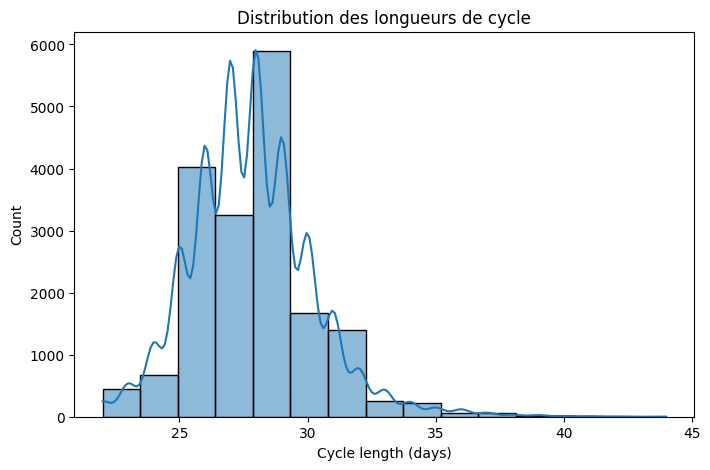

In [11]:
#Visualisations rapides
#Histogramme des longueurs de cycle
plt.figure(figsize=(8,5))
sns.histplot(period_log_processed['cycle_length_days'], bins=15, kde=True)
plt.title("Distribution des longueurs de cycle")
plt.xlabel("Cycle length (days)")
plt.show()

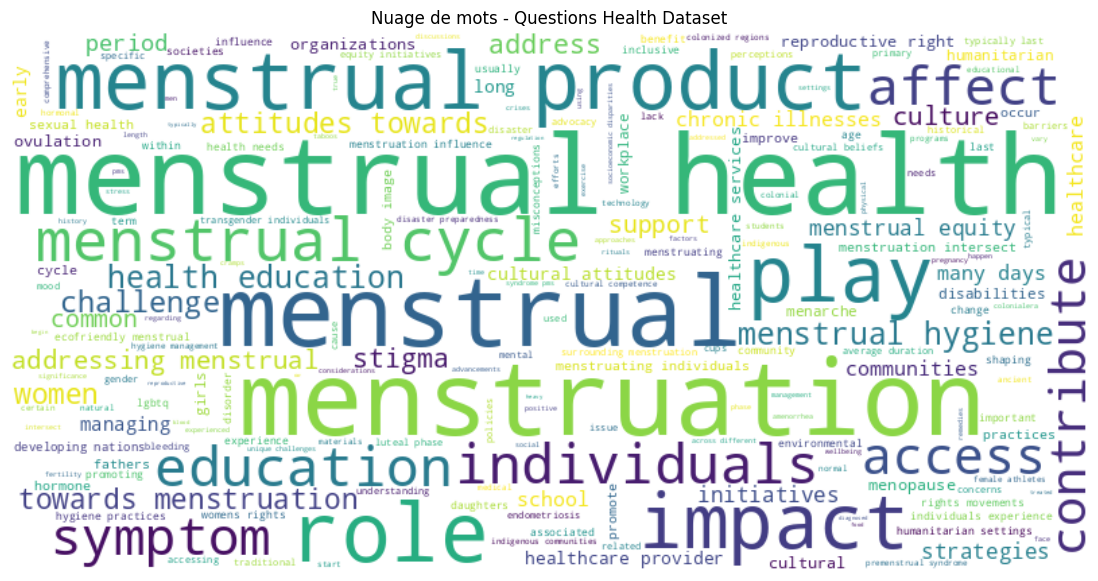

In [12]:
#Nuage de mots pour les questions
from wordcloud import WordCloud
text = ' '.join(train_text['instruction_clean'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuage de mots - Questions Health Dataset")
plt.show()

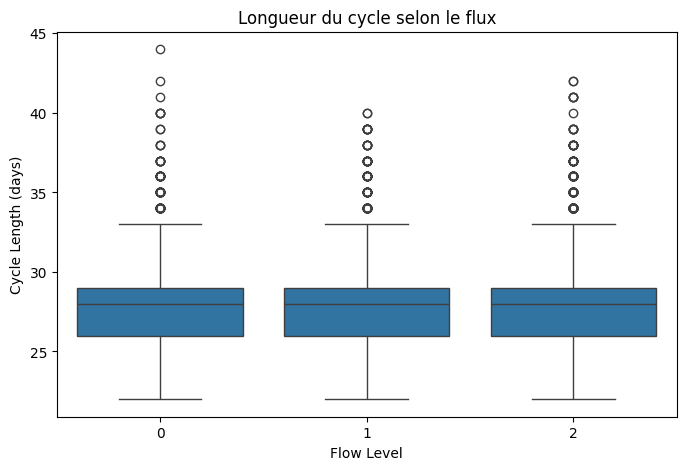

In [13]:
#Boxplot de la longueur du cycle selon le flux
plt.figure(figsize=(8,5))
sns.boxplot(x='flow_level', y='cycle_length_days', data=period_log_processed)
plt.title("Longueur du cycle selon le flux")
plt.xlabel("Flow Level")
plt.ylabel("Cycle Length (days)")
plt.show()

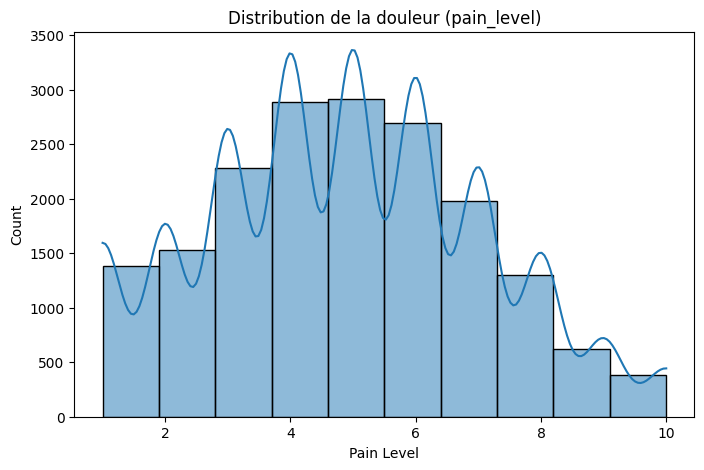

In [14]:
#Histogramme de la douleur (pain_level)
plt.figure(figsize=(8,5))
sns.histplot(period_log_processed['pain_level'], bins=10, kde=True)
plt.title("Distribution de la douleur (pain_level)")
plt.xlabel("Pain Level")
plt.show()

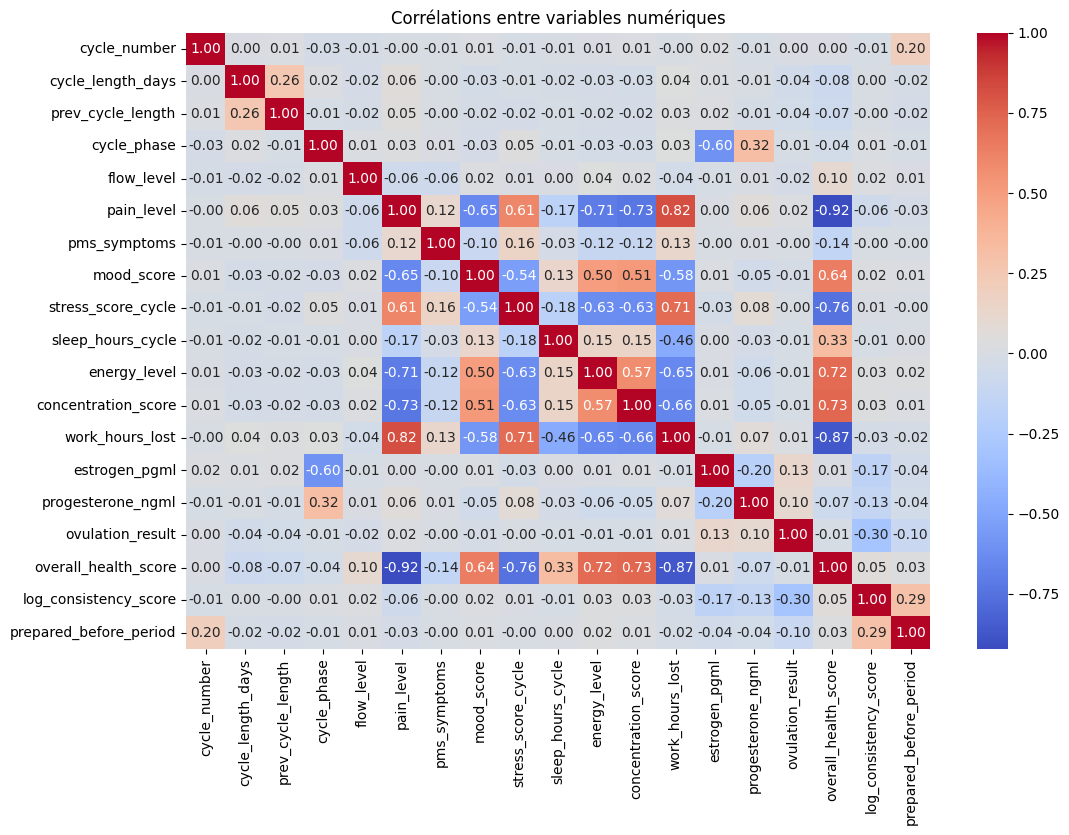

In [15]:
#Heatmap des corrélations numériques
plt.figure(figsize=(12,8))

#Sélectionner uniquement les colonnes numériques pour la corrélation
numeric_cols = period_log_processed.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Corrélations entre variables numériques")
plt.show()

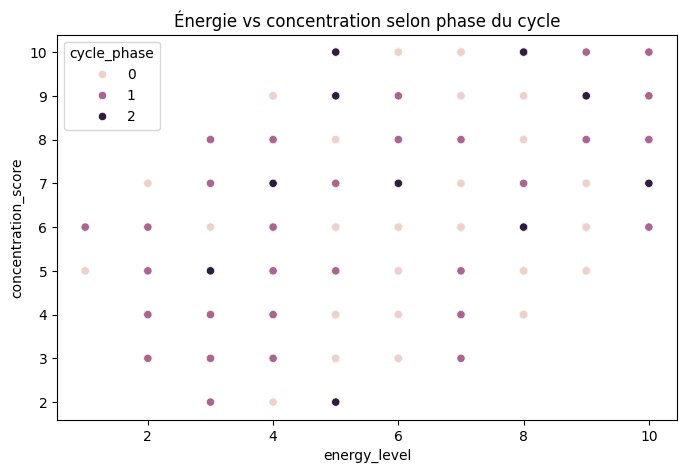

In [16]:
#Scatter plot : énergie vs concentration
plt.figure(figsize=(8,5))
sns.scatterplot(x='energy_level', y='concentration_score', hue='cycle_phase', data=period_log_processed)
plt.title("Énergie vs concentration selon phase du cycle")
plt.show()

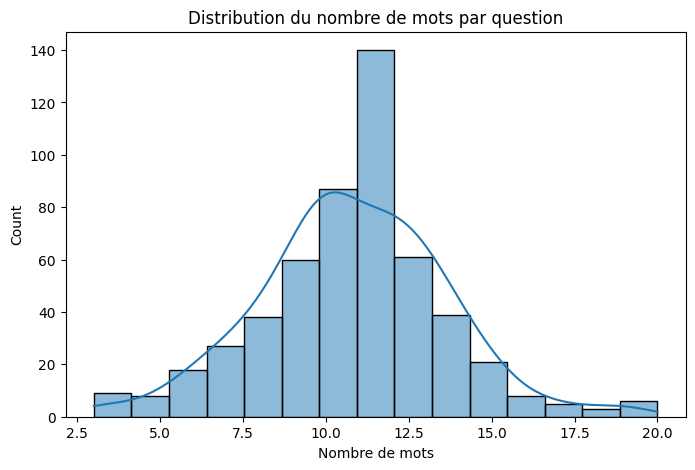

In [17]:
#Nombre de mots par question
train_text['num_words'] = train_text['instruction_clean'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(train_text['num_words'], bins=15, kde=True)
plt.title("Distribution du nombre de mots par question")
plt.xlabel("Nombre de mots")
plt.show()

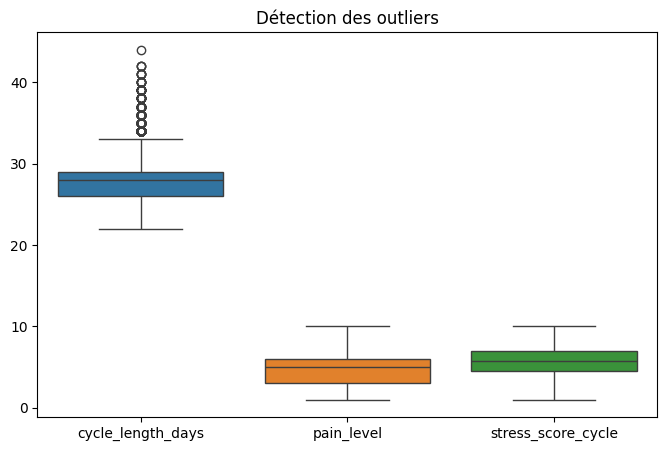

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=period_log_processed[['cycle_length_days','pain_level','stress_score_cycle']])
plt.title("Détection des outliers")
plt.show()

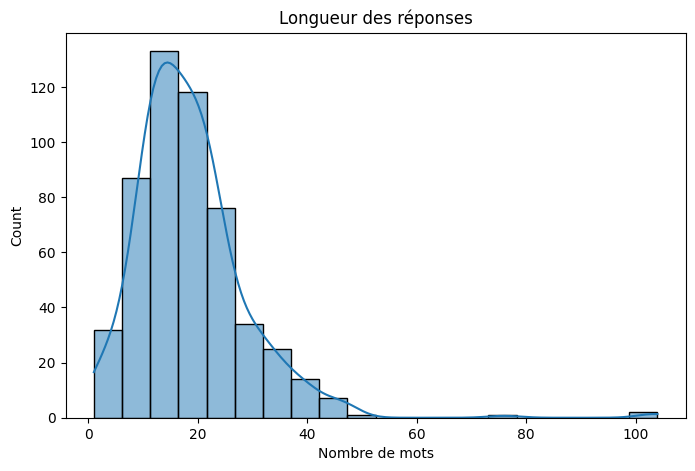

In [19]:
train_text['answer_len'] = train_text['output_clean'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(train_text['answer_len'], bins=20, kde=True)
plt.title("Longueur des réponses")
plt.xlabel("Nombre de mots")
plt.show()

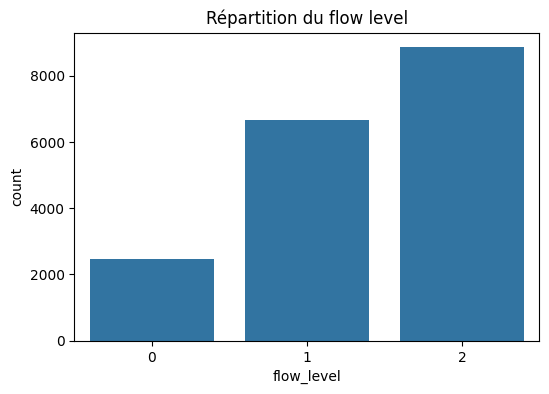

In [20]:
#Flow level
plt.figure(figsize=(6,4))
sns.countplot(x='flow_level', data=period_log_processed)
plt.title("Répartition du flow level")
plt.show()

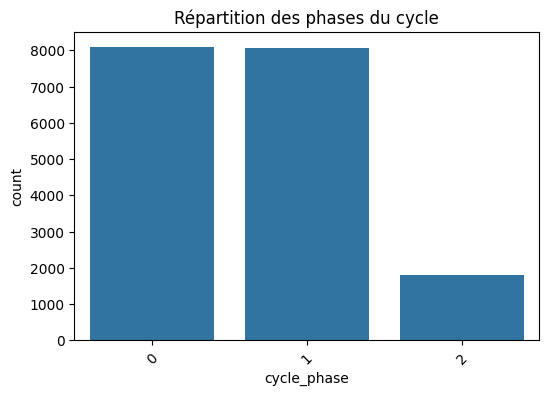

In [21]:
#Cycle phase
plt.figure(figsize=(6,4))
sns.countplot(x='cycle_phase', data=period_log_processed)
plt.title("Répartition des phases du cycle")
plt.xticks(rotation=45)
plt.show()

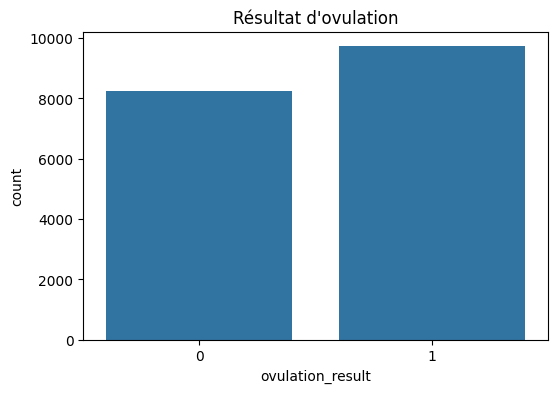

In [22]:
#Ovulation result
plt.figure(figsize=(6,4))
sns.countplot(x='ovulation_result', data=period_log_processed)
plt.title("Résultat d'ovulation")
plt.show()

In [23]:
period_log_processed['ovulation_result'].value_counts()

,count
ovulation_result,
1,9730
0,8246


In [24]:
#Target
y = period_log_processed['ovulation_result']

#Features (on enlève ce qu'il ne faut pas)
X = period_log_processed.drop(columns=[
    'ovulation_result',
    'user_id',
    'start_date'
])

In [25]:
X = pd.get_dummies(X, drop_first=True)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Modèle
model_lr = LogisticRegression(max_iter=1000)

#Entraînement
model_lr.fit(X_train, y_train)

#Prédictions
y_pred = model_lr.predict(X_test)

#Évaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6501668520578421

Classification report:
               precision    recall  f1-score   support

           0       0.64      0.53      0.58      1650
           1       0.65      0.75      0.70      1946

    accuracy                           0.65      3596
   macro avg       0.65      0.64      0.64      3596
weighted avg       0.65      0.65      0.65      3596


Confusion matrix:
 [[ 874  776]
 [ 482 1464]]


In [28]:
from sklearn.ensemble import RandomForestClassifier

#Modèle
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

#Entraînement
model_rf.fit(X_train, y_train)

#Prédictions
y_pred_rf = model_rf.predict(X_test)

#Évaluation
print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print("\nClassification report RF:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion matrix RF:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy RF: 0.6852057842046718

Classification report RF:
               precision    recall  f1-score   support

           0       0.69      0.57      0.62      1650
           1       0.68      0.78      0.73      1946

    accuracy                           0.69      3596
   macro avg       0.69      0.68      0.68      3596
weighted avg       0.69      0.69      0.68      3596


Confusion matrix RF:
 [[ 942  708]
 [ 424 1522]]


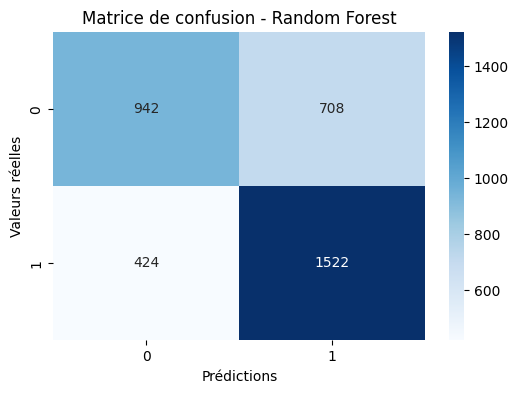

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

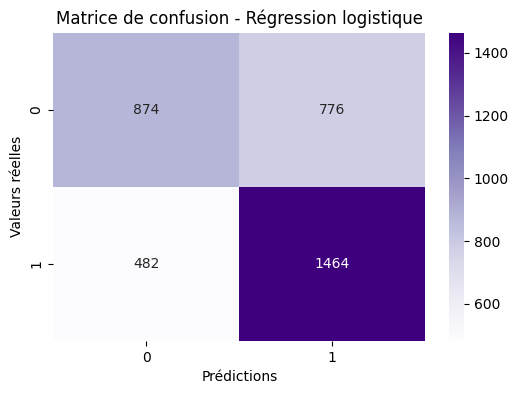

In [30]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Purples")
plt.title("Matrice de confusion - Régression logistique")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

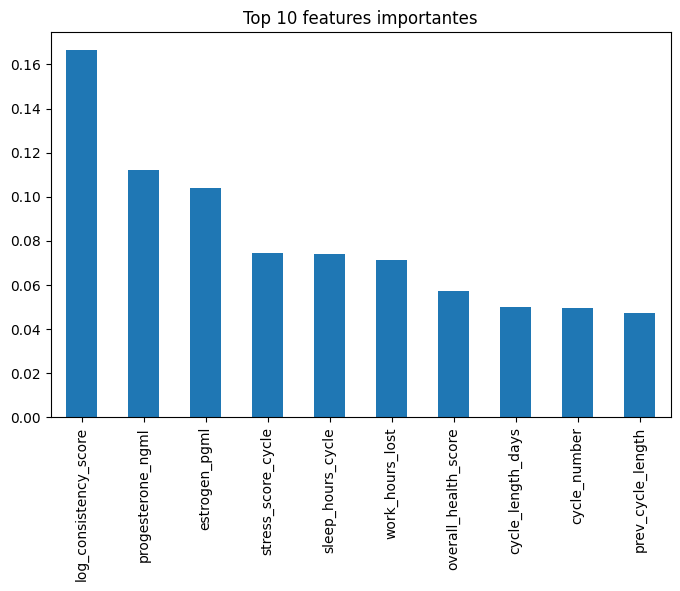

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model_rf.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 features importantes")
plt.show()

L’analyse des importances de variables révèle que les niveaux hormonaux (progestérone et œstrogène), ainsi que la régularité du cycle, constituent les principaux déterminants de la prédiction de l’ovulation.
Ces résultats sont cohérents avec la littérature médicale sur la physiologie du cycle menstruel.

In [32]:
import joblib

joblib.dump(model_rf, "rf_ovulation_model.pkl")

['rf_ovulation_model.pkl']

In [33]:
!pip install xgboost

In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [35]:
#Modèle XGBoost
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

#Train
model_xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = model_xgb.predict(X_test)

#Evaluation
print("Accuracy XGB:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification report XGB:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion matrix XGB:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy XGB: 0.6879866518353727

Classification report XGB:
               precision    recall  f1-score   support

           0       0.69      0.59      0.63      1650
           1       0.69      0.77      0.73      1946

    accuracy                           0.69      3596
   macro avg       0.69      0.68      0.68      3596
weighted avg       0.69      0.69      0.68      3596


Confusion matrix XGB:
 [[ 966  684]
 [ 438 1508]]


In [36]:
!pip -q install transformers datasets evaluate accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [37]:
# On garde uniquement les colonnes utiles
df = train_text[['instruction (string)', 'output (string)']].rename(
    columns={
        'instruction (string)': 'instruction',
        'output (string)': 'output'
    }
).dropna()

df.head()

,instruction,output
0,What is a normal menstrual cycle length?,A normal menstrual cycle typically ranges from...
1,What are common causes of irregular periods?,Common causes of irregular periods include hor...
2,How can I alleviate menstrual cramps?,Menstrual cramps can be alleviated through var...
3,What are the signs of a heavy menstrual flow?,Signs of a heavy menstrual flow include soakin...
4,Is it normal to experience mood swings during ...,"Yes, it is common for some individuals to expe..."


In [38]:
df.head(30)

,instruction,output
0,What is a normal menstrual cycle length?,A normal menstrual cycle typically ranges from...
1,What are common causes of irregular periods?,Common causes of irregular periods include hor...
2,How can I alleviate menstrual cramps?,Menstrual cramps can be alleviated through var...
3,What are the signs of a heavy menstrual flow?,Signs of a heavy menstrual flow include soakin...
4,Is it normal to experience mood swings during ...,"Yes, it is common for some individuals to expe..."
5,How do I know if I have a menstrual disorder?,Signs of a menstrual disorder include irregula...
6,What are some natural remedies for PMS (premen...,Natural remedies for PMS include dietary chang...
7,Can birth control affect my menstrual cycle?,"Yes, birth control methods such as hormonal co..."
8,What are the potential causes of missed period...,Potential causes of missed periods other than ...
9,How can I track my menstrual cycle effectively?,You can track your menstrual cycle by keeping ...


In [39]:
df.columns

Index(['instruction', 'output'], dtype='object')

In [40]:
df.head()

,instruction,output
0,What is a normal menstrual cycle length?,A normal menstrual cycle typically ranges from...
1,What are common causes of irregular periods?,Common causes of irregular periods include hor...
2,How can I alleviate menstrual cramps?,Menstrual cramps can be alleviated through var...
3,What are the signs of a heavy menstrual flow?,Signs of a heavy menstrual flow include soakin...
4,Is it normal to experience mood swings during ...,"Yes, it is common for some individuals to expe..."


In [41]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42
)

In [42]:
len(train_df), len(val_df)

(450, 80)

In [43]:
from datasets import Dataset
from transformers import AutoTokenizer

#Conversion en Dataset HuggingFace
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))

model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_input_len = 128
max_target_len = 192

def preprocess(batch):
    inputs = [
        "Answer the question about menstrual health: " + q
        for q in batch["instruction"]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_len,
        truncation=True
    )

    labels = tokenizer(
        text_target=batch["output"],
        max_length=max_target_len,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
val_tok = val_ds.map(preprocess, batched=True, remove_columns=val_ds.column_names)

train_tok

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 450
})

In [44]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [45]:
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
import evaluate
import numpy as np

# Install rouge_score dependency
!pip install rouge_score

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Ensure predictions are integer token IDs and within valid range
    # First, handle any potential non-finite values (NaN, inf) if they exist
    preds[np.isinf(preds)] = tokenizer.pad_token_id # Replace inf with pad_token
    preds[np.isnan(preds)] = tokenizer.pad_token_id # Replace NaN with pad_token

    # Clip values to ensure they are within the tokenizer's vocabulary range [0, vocab_size-1]
    # and convert to int32 to prevent potential OverflowError in C++ backend
    preds = np.clip(preds, 0, tokenizer.vocab_size - 1).astype(np.int32)

    pred_text = tokenizer.batch_decode(preds, skip_special_tokens=True)
    label_text = tokenizer.batch_decode(labels, skip_special_tokens=True)

    scores = rouge.compute(predictions=pred_text, references=label_text)

    return {
        "rouge1": scores["rouge1"],
        "rougeL": scores["rougeL"],
    }

training_args = Seq2SeqTrainingArguments(
    output_dir="flan_t5_menstrual",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch", # Changed from save_strategy (though 'epoch' is a valid value for save_strategy, we will explicitly set it)
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,   # volontairement petit pour éviter overfitting
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=150,
    load_best_model_at_end=True
)

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=3ba020f9d0f0389967fc5e56fb9a8d79b45600bfff0e7f1d7ffc84f9d43b1f2e
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [46]:
def compute_metrics(eval_pred):

    preds, labels = eval_pred

    # gérer les tuples
    if isinstance(preds, tuple):
        preds = preds[0]

    # remplacer valeurs invalides
    preds = np.where(preds < 0, tokenizer.pad_token_id, preds)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    pred_text = tokenizer.batch_decode(preds, skip_special_tokens=True)
    label_text = tokenizer.batch_decode(labels, skip_special_tokens=True)

    scores = rouge.compute(
        predictions=pred_text,
        references=label_text
    )

    return {
        "rouge1": scores["rouge1"],
        "rougeL": scores["rougeL"],
    }

In [47]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Rouge1,Rougel
1,No log,8.684435,0.205465,0.186426
2,No log,8.445776,0.166366,0.143444
3,No log,8.289624,0.149832,0.141386
4,No log,8.218801,0.138642,0.126121
5,No log,8.187380,0.139943,0.129674


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=285, training_loss=8.821358449835527, metrics={'train_runtime': 1513.4541, 'train_samples_per_second': 1.487, 'train_steps_per_second': 0.188, 'total_flos': 25883800510464.0, 'train_loss': 8.821358449835527, 'epoch': 5.0})

In [48]:
from sentence_transformers import SentenceTransformer, util

# modèle embeddings
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# embeddings des questions
questions = df["instruction"].tolist()
answers = df["output"].tolist()

question_embeddings = embed_model.encode(questions, convert_to_tensor=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [49]:
def retrieve_best_answer(user_question):
    user_emb = embed_model.encode(user_question, convert_to_tensor=True)
    scores = util.cos_sim(user_emb, question_embeddings)[0]

    best_idx = torch.argmax(scores).item()

    return answers[best_idx]

In [50]:
def reformulate_answer(answer_text):

    prompt = f"""
    Rewrite the following medical answer clearly and completely.
    Keep all information.

    Original answer:
    {answer_text}

    Full rewritten answer:
    """

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=200,   # 🔥 plus long
        min_length=40,        # 🔥 évite réponses trop courtes
        do_sample=True,
        top_p=0.9,
        temperature=0.7,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        early_stopping=False  # 🔥 important
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [51]:
def smart_menstrual_assistant(user_question, top_k=3, threshold=0.6):

    user_emb = embed_model.encode(user_question, convert_to_tensor=True)
    scores = util.cos_sim(user_emb, question_embeddings)[0]

    top_results = torch.topk(scores, k=top_k)

    best_score = top_results.values[0].item()

    if best_score < threshold:
        return {
            "final_answer": "I'm not confident enough to answer this question.",
            "alternative_answers": []
        }

    best_answers = [answers[idx.item()] for idx in top_results.indices]

    return {
        "final_answer": best_answers[0],
        "alternative_answers": best_answers[1:]
    }

In [52]:
result = smart_menstrual_assistant("I feel strong pain during my period, what can help me?")

print(result)

{'final_answer': 'Menstrual cramps can be alleviated through various methods including over-the-counter pain relievers, applying heat to the abdomen, gentle exercise, relaxation techniques, and dietary changes.', 'alternative_answers': ['Yes, there are several ways to manage menstrual discomfort, including over-the-counter pain relievers (such as ibuprofen or acetaminophen), applying heat to the abdomen, staying hydrated, getting regular exercise, and practicing relaxation techniques like yoga or meditation.', 'Menstrual cramps, also known as dysmenorrhea, occur due to the contraction of the uterus as it sheds its lining during menstruation. Increased levels of prostaglandins, hormone-like substances, contribute to uterine muscle contractions and pain.']}
